In [2]:
import floralarea
from floralarea.cv import yolov8, img_processing as ip
import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [10]:
# Load config
with open('../../config/config.json') as f:
    config = json.load(f)

In [11]:
model = yolov8(
    config['flower_model'],
    config['reference_object_model']
)

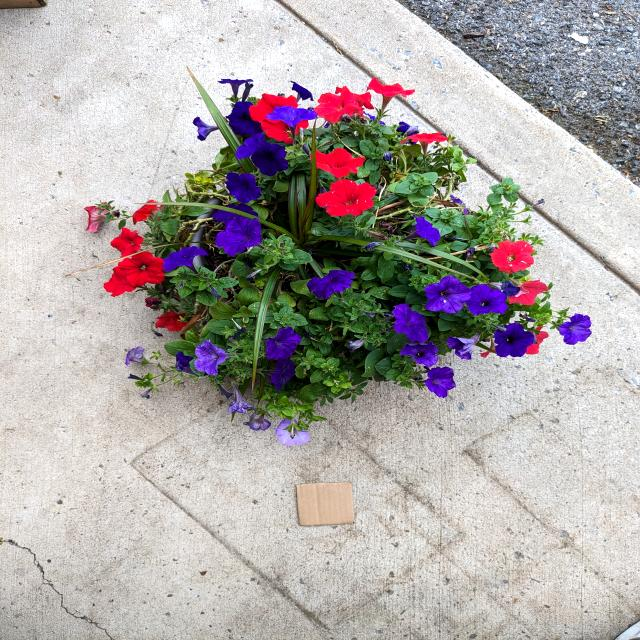

In [21]:
# Preprocess image
filename = '/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/test_image2.jpg'
ip.apply_preprocessing(filename)

In [22]:
# Estimate floral area
component_area, image = floralarea.cv.runTilles(
    model, 
    filename, 
    threshold=0.5, 
    num_tiles=2, 
    component='flower'
)


image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_0_0.jpg: 640x640 22 flowers, 412.0ms
Speed: 7.9ms preprocess, 412.0ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_0_1.jpg: 640x640 17 flowers, 243.7ms
Speed: 1.4ms preprocess, 243.7ms inference, 16.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_1_0.jpg: 640x640 8 flowers, 226.2ms
Speed: 1.3ms preprocess, 226.2ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_1_1.jpg: 640x640 7 flowers, 221.5ms
Speed: 1.3ms preprocess, 221.5ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)


In [28]:
results = model.runInference(filename, 'reference_object', 0.5)
mask = model.getMask(results)
reference_pixel_area = ip.getPixelArea(mask)


image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/test_image2.jpg: 640x640 2 reference_objects, 301.4ms
Speed: 1.1ms preprocess, 301.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


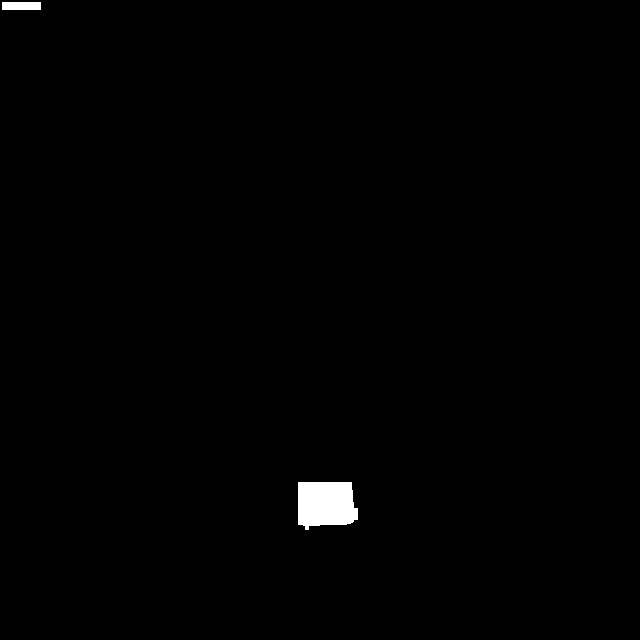

In [29]:
mask 

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [47]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import requests

device = "cuda" if torch.cuda.is_available() else "cpu" # also try "mps" for Mac M1/M2



model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 1428.04it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


In [59]:
# Load image
#image_url = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/crown_images/1_186..jpg"
image_url = '/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/crown_images/1_193..jpg'
image = Image.open(image_url).convert("RGB")

# Segment using text prompt
inputs = processor(images=image, text="alive flower", return_tensors="pt").to(device)

#inputs = processor(images=image, text="brown square cardboard", return_tensors="pt").to(device)


with torch.no_grad():
    outputs = model(**inputs)

# Post-process results
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.7,
    target_sizes=inputs.get("original_sizes").tolist(),

)[0]

print(f"Found {len(results['masks'])} objects")
# Results contain:
# - masks: Binary masks resized to original image size
# - boxes: Bounding boxes in absolute pixel coordinates (xyxy format)
# - scores: Confidence scores

Found 27 objects


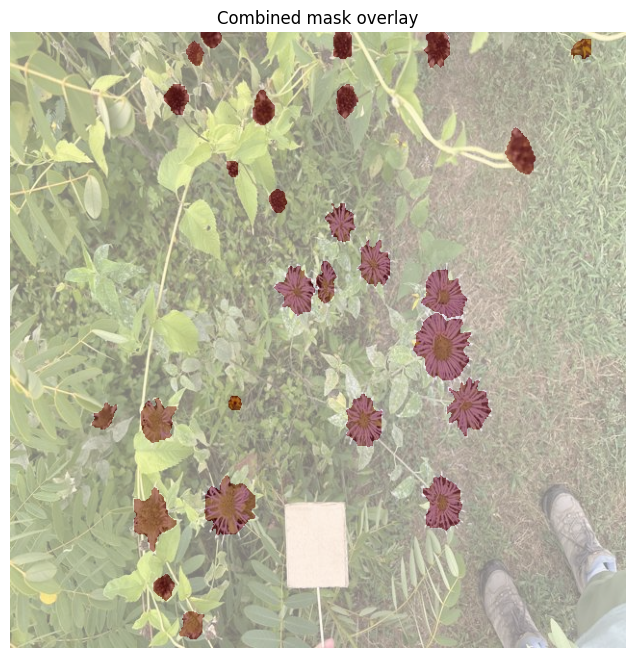

In [60]:
# make masks_np available (accepts torch tensor or numpy array)
masks = results.get('masks') if isinstance(results, dict) else None
if masks is None and hasattr(outputs, "pred_masks"):
    masks = outputs.pred_masks
if masks is None:
    raise ValueError("No 'masks' found in `results` or `outputs`")

# convert to numpy (N, H, W)
if hasattr(masks, "cpu"):
    masks_np = masks.cpu().numpy()
else:
    masks_np = np.array(masks)

# if masks are logits/float, convert to binary by sigmoid + threshold
if masks_np.dtype.kind in ("f", "i") and masks_np.max() > 1:
    masks_np = (1.0 / (1.0 + np.exp(-masks_np))) > 0.5
else:
    masks_np = masks_np.astype(bool)

# combine all predicted masks into one binary mask and overlay on the image
combined_mask = np.any(masks_np.astype(bool), axis=0)  # shape (H, W), bool

# resize mask if it doesn't match image size
img_w, img_h = image.size
mask_h, mask_w = combined_mask.shape
if (mask_w, mask_h) != (img_w, img_h):
    mask_pil = Image.fromarray((combined_mask * 255).astype(np.uint8)).resize((img_w, img_h), resample=Image.NEAREST)
    combined_mask = np.array(mask_pil) > 0

# show overlay
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.imshow(combined_mask, cmap="Reds", alpha=0.5)
plt.title("Combined mask overlay")
plt.axis("off")
plt.show()

# optional: save combined mask and overlay to files
combined_mask_img = Image.fromarray((combined_mask * 255).astype(np.uint8))
combined_mask_img.save("combined_mask.png")

overlay = Image.new("RGBA", image.size)
red = Image.new("RGBA", image.size, (255,0,0,120))
overlay.paste(red, mask=combined_mask_img)
composite = Image.alpha_composite(image.convert("RGBA"), overlay)
#composite.save("combined_mask_overlay.png")


In [1]:
# Test system info
import floralarea
floralarea.print_system_info()

# Test measurement
from floralarea import FloralAreaAnalyzer

#output_folder = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output_FloralSuite_Evaluation"
output_folder = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output_Paper1_Evaluation"

analyzer = FloralAreaAnalyzer(camera_model='pixel_6', output_dir= output_folder , enable_dead_flower_filter= False)

FloralArea v1.0.0

📦 Component Status:
----------------------------------------------------------------------
  ✅ Core (FloralAreaAnalyzer)
  ✅ SAM 3 Segmentation (HuggingFace)
     Device: mps
  ✅ Distance-based Measurement (LiDAR-ready)
----------------------------------------------------------------------

✅ FloralArea is ready to use!

Quick start:
  >>> from floralarea import FloralAreaAnalyzer
  >>> analyzer = FloralAreaAnalyzer()
  >>> result = analyzer.measure('flower.jpg')
  >>> print(f"Area: {result['area_cm2']:.2f} cm²")
Initializing Floral Area Analyzer V2...
  Camera: pixel_6
  Dead flower filtering: Disabled
  Output directory: /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output_Paper1_Evaluation
  Loading SAM3 Improved...


/Users/edwardamoah/Documents/GitHub/FloralArea_Web/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SAM3: facebook/sam3
Device: mps


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 1525.46it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


✓ SAM3 loaded!
✓ Analyzer V2 ready!


In [2]:
import os
folder_path = "/Users/edwardamoah/Downloads/evaluation_images_experiment_1" # PAPER1 EVALUATION
#folder_path = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/crown_images" # FLORALSUITE_EVALUATION
files = os.listdir(folder_path)

In [3]:
import pandas as pd
import numpy as np

In [4]:
data = pd.DataFrame(
    {
        "filename": files
    }
)

In [5]:
files = [os.path.join(folder_path, f) for f in files]

In [6]:
# just jpg files
files = [f for f in files if f.lower().endswith('.jpg')]

In [7]:
len(files)

75

In [8]:
# # /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output_Paper1_Evaluation/PXL_20240214_174443010_80cm_F14__segmentation.jpg
# fl = [file for file in files if 'PXL_20240214_174443010_80cm_F14' in file]
# fl

In [9]:
# analyzer.measure(fl[0], flower_threshold=0.15, scene_type = 'outdoor')

In [50]:
results = analyzer.measure_batch(files, flower_threshold=0.50, scene_type = 'indoor')


BATCH MEASUREMENT V2: 75 images

[1/75] Processing PXL_20240214_172530114_80cm_F6_.jpg

Measuring: PXL_20240214_172530114_80cm_F6_.jpg

📸 Segmenting flowers and reference (separate calls)...
   Flower: mask_threshold=0.7
Segmenting 'flower' (mask_threshold=0.7)...
✓ Found 4 instances
   ✅ Flowers: 4 detections
   Reference: mask_threshold=0.3 (adaptive)
Segmenting 'brown square cardboard' (mask_threshold=0.3)...
✓ Found 1 instances
   ✅ Reference: 1 detections

🔧 Removing overlapping detections (vectorized NMS)...

   Step 2: Scene-adaptive filtering...
      Scene type: INDOOR (4 flowers, user-specified)
      Applying adaptive oversegmentation filter...
   📏 Adaptive threshold: Q3=11.9 + 1.5×IQR=1.0 = 13.4 cm²
   ✅ Final flower pixels: 70,707

📏 Reference quality control...

📏 Processing reference object...
  Single reference detected:
    Aspect ratio: 1.013
    Squareness: 0.980
    ✓ Reference is acceptable
  Reference is square (AR=1.013) - no occlusion correction
  ✓ Reference 

In [51]:
# 17 s with use_combined = False
# running use_combined = True gives 9 s

In [52]:
results_df = pd.DataFrame(results)

In [53]:
df = results_df[["area_cm2","image_path"]]

In [54]:
df['filename'] = df['image_path'].apply(lambda x: os.path.basename(x))

/var/folders/r5/48dgr3g12qg3cwmg9f6v0cwc0000gn/T/ipykernel_18655/3222653218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['filename'] = df['image_path'].apply(lambda x: os.path.basename(x))


In [55]:
df

,area_cm2,image_path,filename
0,45.372639,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_172530114_80cm_F6_.jpg
1,3.303557,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_173554009_80cm_F11_.jpg
2,32.584215,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_175708911_100cm_F23_.jpg
3,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_175352365_100cm_F21_.jpg
4,131.530978,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_174000188_80cm_F13_.jpg
...,...,...,...
70,11.318141,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_172357833_80cm_F5_.jpg
71,3.450452,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_173607901_60cm_F11_.jpg
72,55.910964,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_174741393_100cm_F16_.jpg
73,36.670874,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_172516412_100cm_F6_.jpg


In [56]:
df.to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_50.csv', index=False)

In [57]:
df['predicted_area_cm2'] = df['area_cm2']
df = df[['filename', 'predicted_area_cm2']]

/var/folders/r5/48dgr3g12qg3cwmg9f6v0cwc0000gn/T/ipykernel_18655/3773085584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_area_cm2'] = df['area_cm2']


In [90]:
df = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_50.csv')

In [92]:
data1 = pd.read_csv("/Users/edwardamoah/Downloads/floralarea_experiment_1 - floralarea.csv")

In [93]:
def incheas_to_cm2(area_in_inches2):
    return area_in_inches2 * 6.4516

In [94]:
data1.head()

,images,flower_number,distance,imagej_area,flower_color,morphology,Notes
0,PXL_20240214_172530114_80cm_F6_.jpg,F6,80cm,7.953,T1,C1,NaN
1,PXL_20240214_173554009_80cm_F11_.jpg,F11,80cm,0.522,T5,C3,NaN
2,PXL_20240214_175708911_100cm_F23_.jpg,F23,100cm,5.567,T3,C2,Area is off
3,PXL_20240214_175352365_100cm_F21_.jpg,F21,100cm,3.053,T2,C2,NaN
4,PXL_20240214_174000188_80cm_F13_.jpg,F13,80cm,20.396,T4,C3,NaN


In [95]:
data1['measured_area_cm2'] = data1['imagej_area'].apply(incheas_to_cm2)

In [96]:
data1['filename'] = data1['images']
data2 = data1[['measured_area_cm2', 'filename']].merge(df, on='filename')

In [97]:
data2

,measured_area_cm2,filename,area_cm2,image_path
0,51.309575,PXL_20240214_172530114_80cm_F6_.jpg,45.372639,/Users/edwardamoah/Downloads/evaluation_images...
1,3.367735,PXL_20240214_173554009_80cm_F11_.jpg,3.303557,/Users/edwardamoah/Downloads/evaluation_images...
2,35.916057,PXL_20240214_175708911_100cm_F23_.jpg,32.584215,/Users/edwardamoah/Downloads/evaluation_images...
3,19.696735,PXL_20240214_175352365_100cm_F21_.jpg,18.239009,/Users/edwardamoah/Downloads/evaluation_images...
4,131.586834,PXL_20240214_174000188_80cm_F13_.jpg,131.530978,/Users/edwardamoah/Downloads/evaluation_images...
...,...,...,...,...
70,18.845124,PXL_20240214_172357833_80cm_F5_.jpg,11.318141,/Users/edwardamoah/Downloads/evaluation_images...
71,3.535477,PXL_20240214_173607901_60cm_F11_.jpg,3.450452,/Users/edwardamoah/Downloads/evaluation_images...
72,54.606342,PXL_20240214_174741393_100cm_F16_.jpg,55.910964,/Users/edwardamoah/Downloads/evaluation_images...
73,41.935400,PXL_20240214_172516412_100cm_F6_.jpg,36.670874,/Users/edwardamoah/Downloads/evaluation_images...


In [98]:
data2['predicted_area_cm2'] = data2['area_cm2'].astype(float)

In [103]:
data2['file'] = data2['filename']

In [ ]:
#data2[['file', 'measured_area_cm2', 'predicted_area_cm2']].to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_analysis_data.csv', index=False)

In [106]:
from matplotlib import pyplot as plt

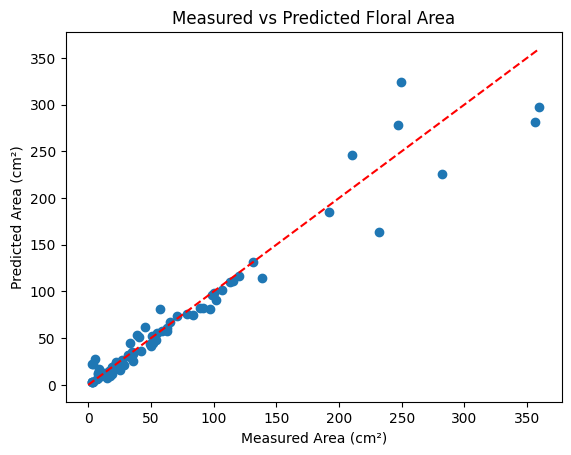

In [107]:
plt.scatter(data2['measured_area_cm2'], data2['predicted_area_cm2'])
plt.xlabel('Measured Area (cm²)')
plt.ylabel('Predicted Area (cm²)')
plt.title('Measured vs Predicted Floral Area')
plt.plot([0, max(data2['measured_area_cm2'])], [0, max(data2['measured_area_cm2'])], 'r--')  # 45-degree line
plt.show()

Total samples: 75  Outliers detected: 14


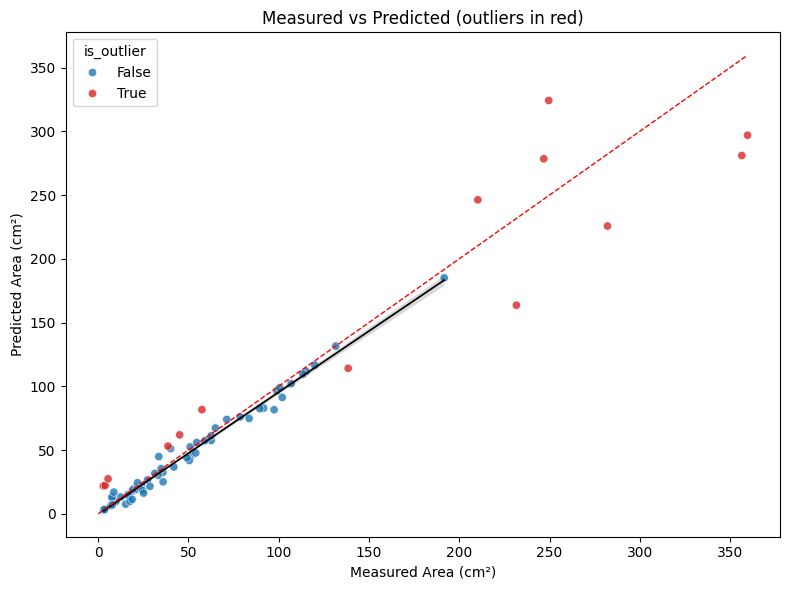

R² (all valid samples): 0.935796371231877
R² (without outliers): 0.9807383820639562


In [108]:
import seaborn as sns
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

# work on a copy
df = data2.dropna(subset=['measured_area_cm2', 'predicted_area_cm2']).copy()

df['bias'] = df['predicted_area_cm2'] - df['measured_area_cm2']

# use bias (predicted - measured) to find outliers via IQR
Q1 = df['bias'].quantile(0.25)
Q3 = df['bias'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['bias'] < (Q1 - 1.5 * IQR)) | (df['bias'] > (Q3 + 1.5 * IQR))
df['is_outlier'] = outlier_mask

print(f"Total samples: {len(df)}  Outliers detected: {df['is_outlier'].sum()}")

# scatter with outliers highlighted
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='measured_area_cm2',
    y='predicted_area_cm2',
    hue='is_outlier',
    palette={False: 'tab:blue', True: 'tab:red'},
    alpha=0.8
)
# regression line on non-outliers
non_out = df[~df['is_outlier']]
if len(non_out) > 1:
    sns.regplot(
        data=non_out,
        x='measured_area_cm2',
        y='predicted_area_cm2',
        scatter=False,
        color='black',
        line_kws={'linewidth':1.25}
    )

# 45-degree reference line
max_val = max(df['measured_area_cm2'].max(), df['predicted_area_cm2'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1)
plt.xlabel('Measured Area (cm²)')
plt.ylabel('Predicted Area (cm²)')
plt.title('Measured vs Predicted (outliers in red)')
plt.legend(title='is_outlier')
plt.tight_layout()
plt.show()

# compute R² before and after removing outliers
y_true_arr = df['measured_area_cm2'].to_numpy()
y_pred_arr = df['predicted_area_cm2'].to_numpy()
mask_valid = ~np.isnan(y_true_arr) & ~np.isnan(y_pred_arr)

r2_all = np.nan
r2_no_out = np.nan
if mask_valid.sum() > 0:
    try:
        r2_all = r2_score(y_true_arr[mask_valid], y_pred_arr[mask_valid])
    except Exception:
        r2_all = np.nan

no_out_mask = mask_valid & (~df['is_outlier'].to_numpy())
if no_out_mask.sum() > 0:
    try:
        r2_no_out = r2_score(y_true_arr[no_out_mask], y_pred_arr[no_out_mask])
    except Exception:
        r2_no_out = np.nan

print(f"R² (all valid samples): {r2_all}")
print(f"R² (without outliers): {r2_no_out}")

# produce a cleaned dataframe for downstream use
data2_clean = df[~df['is_outlier']].drop(columns=['is_outlier']).reset_index(drop=True)

In [54]:
data2_clean

,measured_area_cm2,filename,predicted_area_cm2,bias
0,51.309575,PXL_20240214_172530114_80cm_F6_.jpg,48.446379,-2.863195
1,3.367735,PXL_20240214_173554009_80cm_F11_.jpg,3.346439,-0.021296
2,35.916057,PXL_20240214_175708911_100cm_F23_.jpg,33.417320,-2.498737
3,19.696735,PXL_20240214_175352365_100cm_F21_.jpg,18.239009,-1.457725
4,131.586834,PXL_20240214_174000188_80cm_F13_.jpg,136.710769,5.123935
...,...,...,...,...
57,18.845124,PXL_20240214_172357833_80cm_F5_.jpg,30.537958,11.692834
58,3.535477,PXL_20240214_173607901_60cm_F11_.jpg,3.451112,-0.084365
59,54.606342,PXL_20240214_174741393_100cm_F16_.jpg,57.630021,3.023679
60,41.935400,PXL_20240214_172516412_100cm_F6_.jpg,36.670874,-5.264526


In [55]:
data2_clean['bias'] = data2_clean['predicted_area_cm2'] - data2_clean['measured_area_cm2']

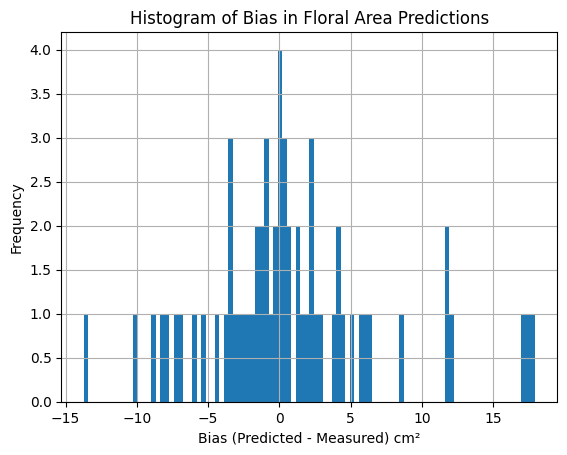

In [56]:
data2_clean['bias'].hist(bins=100)
plt.xlabel('Bias (Predicted - Measured) cm²')
plt.ylabel('Frequency')
plt.title('Histogram of Bias in Floral Area Predictions')
plt.show()

In [57]:
def getRelativeBias(row):
    return (row['predicted_area_cm2'] - row['measured_area_cm2']) / row['measured_area_cm2'] * 100

data2_clean['relative_bias'] = data2_clean.apply(getRelativeBias, axis=1)

Text(0.5, 1.0, 'Histogram of Relative Bias in Floral Area Predictions')

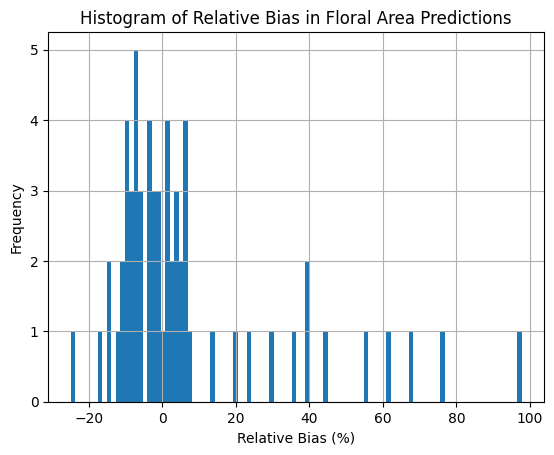

In [58]:
data2_clean['relative_bias'].hist(bins=100)
plt.xlabel('Relative Bias (%)')
plt.ylabel('Frequency')
plt.title('Histogram of Relative Bias in Floral Area Predictions')

In [67]:
##### Papaer 2 Analysis ######
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
import seaborn as sns

In [68]:
data = pd.read_csv("/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/outdoor.csv")

In [69]:
data['file'] = data['filename'].apply(lambda x: int(x.replace('..jpg', '').split("_")[1] ))

In [70]:
data['predicted_area_cm2'] = data['area_cm2']

In [71]:
data1 = pd.read_csv("/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/ground_truth_floral_suite.csv")

In [72]:
data1['file'] = data1['filename']

In [73]:
data2 = data1[['measured_area_cm2', 'file']].merge(data[['predicted_area_cm2', 'file']], on='file')

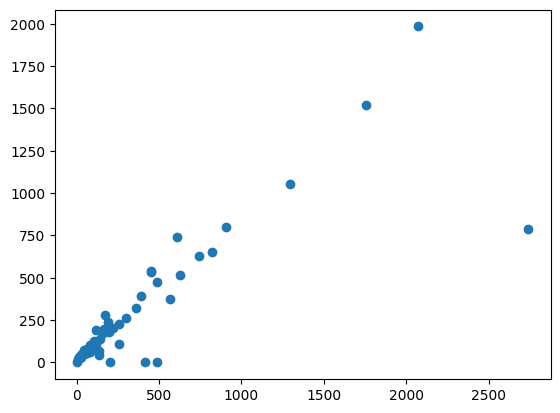

In [74]:
plt.scatter(data2['measured_area_cm2'], data2['predicted_area_cm2'])

In [75]:
# get R2 score
r2 = r2_score(data2['measured_area_cm2'], data2['predicted_area_cm2'])
r2

0.7045378998563112

Total samples: 61  Outliers detected: 10


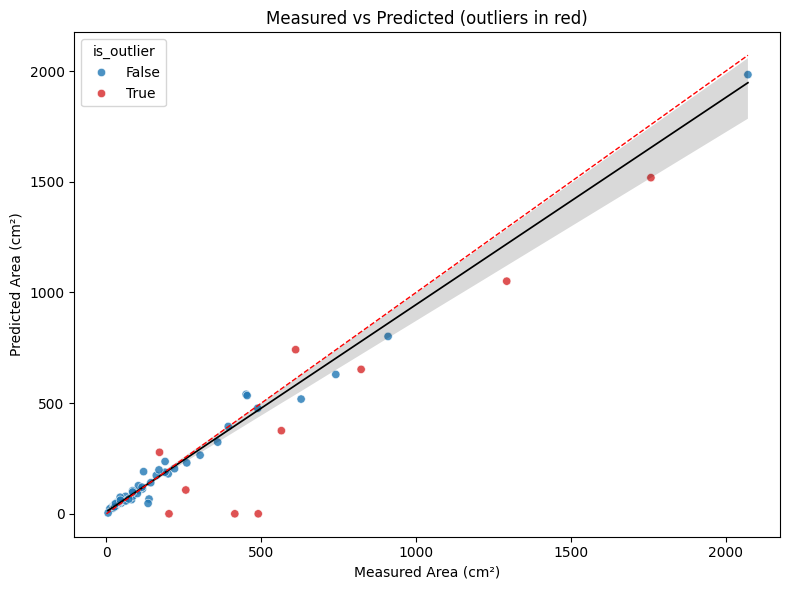

R² (all valid samples): 0.9189277205725985
R² (without outliers): 0.9838057490194474


In [84]:
import seaborn as sns
from sklearn.metrics import r2_score
import numpy as np

import matplotlib.pyplot as plt

# work on a copy
df = data2.dropna(subset=['measured_area_cm2', 'predicted_area_cm2']).copy()

# df without 177
df = df[df['file'] != 177].copy()
# df = df[df['file'] != 210].copy()
# df = df[df['file'] != 220].copy()
# df = df[df['file'] != 217].copy()


df['bias'] = df['predicted_area_cm2'] - df['measured_area_cm2']

# use bias (predicted - measured) to find outliers via IQR
Q1 = df['bias'].quantile(0.25)
Q3 = df['bias'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['bias'] < (Q1 - 1.5 * IQR)) | (df['bias'] > (Q3 + 1.5 * IQR))
df['is_outlier'] = outlier_mask

print(f"Total samples: {len(df)}  Outliers detected: {df['is_outlier'].sum()}")

# scatter with outliers highlighted
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='measured_area_cm2',
    y='predicted_area_cm2',
    hue='is_outlier',
    palette={False: 'tab:blue', True: 'tab:red'},
    alpha=0.8
)
# regression line on non-outliers
non_out = df[~df['is_outlier']]
if len(non_out) > 1:
    sns.regplot(
        data=non_out,
        x='measured_area_cm2',
        y='predicted_area_cm2',
        scatter=False,
        color='black',
        line_kws={'linewidth':1.25}
    )

# 45-degree reference line
max_val = max(df['measured_area_cm2'].max(), df['predicted_area_cm2'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1)
plt.xlabel('Measured Area (cm²)')
plt.ylabel('Predicted Area (cm²)')
plt.title('Measured vs Predicted (outliers in red)')
plt.legend(title='is_outlier')
plt.tight_layout()
plt.show()

# compute R² before and after removing outliers
y_true_arr = df['measured_area_cm2'].to_numpy()
y_pred_arr = df['predicted_area_cm2'].to_numpy()
mask_valid = ~np.isnan(y_true_arr) & ~np.isnan(y_pred_arr)

r2_all = np.nan
r2_no_out = np.nan
if mask_valid.sum() > 0:
    try:
        r2_all = r2_score(y_true_arr[mask_valid], y_pred_arr[mask_valid])
    except Exception:
        r2_all = np.nan

no_out_mask = mask_valid & (~df['is_outlier'].to_numpy())
if no_out_mask.sum() > 0:
    try:
        r2_no_out = r2_score(y_true_arr[no_out_mask], y_pred_arr[no_out_mask])
    except Exception:
        r2_no_out = np.nan

print(f"R² (all valid samples): {r2_all}")
print(f"R² (without outliers): {r2_no_out}")

# produce a cleaned dataframe for downstream use
data2_clean = df[~df['is_outlier']].drop(columns=['is_outlier']).reset_index(drop=True)

In [79]:
data2[data2['predicted_area_cm2'] == 0]

,measured_area_cm2,file,predicted_area_cm2
33,414.469,210,0.0
38,201.930,217,0.0
41,490.149,220,0.0


In [80]:
data2[data2['measured_area_cm2'] > 2500]

,measured_area_cm2,file,predicted_area_cm2
4,2741.262,177,790.458068


In [89]:
df[['file', 'measured_area_cm2', 'predicted_area_cm2']].to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/outdoor_analysis_data.csv', index=False)

In [109]:
data2.head()

,measured_area_cm2,filename,area_cm2,image_path,predicted_area_cm2,file
0,51.309575,PXL_20240214_172530114_80cm_F6_.jpg,45.372639,/Users/edwardamoah/Downloads/evaluation_images...,45.372639,PXL_20240214_172530114_80cm_F6_.jpg
1,3.367735,PXL_20240214_173554009_80cm_F11_.jpg,3.303557,/Users/edwardamoah/Downloads/evaluation_images...,3.303557,PXL_20240214_173554009_80cm_F11_.jpg
2,35.916057,PXL_20240214_175708911_100cm_F23_.jpg,32.584215,/Users/edwardamoah/Downloads/evaluation_images...,32.584215,PXL_20240214_175708911_100cm_F23_.jpg
3,19.696735,PXL_20240214_175352365_100cm_F21_.jpg,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,18.239009,PXL_20240214_175352365_100cm_F21_.jpg
4,131.586834,PXL_20240214_174000188_80cm_F13_.jpg,131.530978,/Users/edwardamoah/Downloads/evaluation_images...,131.530978,PXL_20240214_174000188_80cm_F13_.jpg


In [110]:
###### Experiment 3 ######

#Experiment with distance based measurement with indoor data

# 1. Find the distance from camera to flower using reference object measurment for each flower at 80cm 
# 2. Use the known distance to flower to estimate distance of flower to ground. 
# 3. Use known distance of flower to ground to estimate distance of flower to camera for other distances (60cm, 100cm)
# 4. Note PXL_20240214_172530114_80cm_F6_.jpg, the flowers in this case is F6, and the distance from camera to ground is 80cm 


In [1]:
# Test system info
import floralarea
floralarea.print_system_info()

# Test measurement
from floralarea import FloralAreaAnalyzer

#output_folder = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output_FloralSuite_Evaluation"
#output_folder = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output_Paper1_Evaluation"
output_folder = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment"

analyzer = FloralAreaAnalyzer(camera_model='pixel_6', output_dir= output_folder , enable_dead_flower_filter= False)

FloralArea v1.0.0

📦 Component Status:
----------------------------------------------------------------------
  ✅ Core (FloralAreaAnalyzer)
  ✅ SAM 3 Segmentation (HuggingFace)
     Device: mps
  ✅ Distance-based Measurement (LiDAR-ready)
----------------------------------------------------------------------

✅ FloralArea is ready to use!

Quick start:
  >>> from floralarea import FloralAreaAnalyzer
  >>> analyzer = FloralAreaAnalyzer()
  >>> result = analyzer.measure('flower.jpg')
  >>> print(f"Area: {result['area_cm2']:.2f} cm²")
Initializing Floral Area Analyzer V2...
  Camera: pixel_6
  Dead flower filtering: Disabled
  Output directory: /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment
  Loading SAM3 Improved...


/Users/edwardamoah/Documents/GitHub/FloralArea_Web/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SAM3: facebook/sam3
Device: mps


Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 1277.52it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


✓ SAM3 loaded!
✓ Analyzer V2 ready!


In [2]:
test_file = "/Users/edwardamoah/Downloads/evaluation_images_experiment_1/PXL_20240214_175233333_100cm_F20_.jpg"

In [4]:
result = analyzer.measure(test_file, flower_threshold=0.5, scene_type = 'indoor', flower_distance_cm=80, camera_model ='pixel_6')


Measuring: PXL_20240214_175233333_100cm_F20_.jpg

📸 Segmenting flowers and reference (separate calls)...
   Flower: mask_threshold=0.7
Segmenting 'flower' (mask_threshold=0.7)...
✓ Found 19 instances
   ✅ Flowers: 19 detections
   Reference: mask_threshold=0.3 (adaptive)
Segmenting 'brown square cardboard' (mask_threshold=0.3)...
✓ Found 0 instances
   🔍 No reference at threshold 0.50, trying lower thresholds...
Segmenting 'brown square cardboard' (mask_threshold=0.3)...
✓ Found 1 instances
   🔍 Reference found with adaptive threshold 0.45 (attempt 2)
   ✅ Reference: 1 detections

🔧 Removing overlapping detections (vectorized NMS)...

   Step 2: Scene-adaptive filtering...
      Scene type: INDOOR (19 flowers, user-specified)
      Applying adaptive oversegmentation filter...
   📏 Adaptive threshold: Q3=6.6 + 1.5×IQR=3.9 = 12.5 cm²
   ✅ Final flower pixels: 99,517

📏 Reference quality control...

📏 Processing reference object...
  Single reference detected:
    Aspect ratio: 1.060
   

In [5]:
result

{'area_cm2': 81.57592288993159,
 'method': 'reference_based',
 'confidence': 'HIGH',
 'error_estimate': '±2-5%',
 'flower_pixels': 99517,
 'num_detections_filtered': 19,
 'num_flowers_before_filter': 19,
 'num_dead_flowers_removed': 0,
 'image_path': '/Users/edwardamoah/Downloads/evaluation_images_experiment_1/PXL_20240214_175233333_100cm_F20_.jpg',
 'all_methods': {'reference': {'area_cm2': 81.57592288993159,
   'method': 'reference_based',
   'confidence': 'HIGH',
   'flower_pixels': 99517,
   'ref_pixels': 70756,
   'ref_squareness': 0.9142589484390989,
   'ref_occlusion_corrected': True,
   'num_flower_detections': 19,
   'num_flowers_before_filter': 19,
   'num_dead_flowers_removed': 0,
   'error_estimate': '±2-5%'},
  'distance': {'area_cm2': 85.49831640884466,
   'method': 'distance',
   'confidence': 'MEDIUM',
   'distance_cm': 80,
   'camera': 'Pixel 6',
   'focal_length_px': 2729.3538461538465,
   'pixel_area': 99517,
   'real_width_cm': 18.319354256854254,
   'real_height_cm

In [8]:
import pandas as pd
import numpy as np

In [9]:
data = pd.read_csv("/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_analysis_data.csv")

In [10]:
folder = "/Users/edwardamoah/Downloads/evaluation_images_experiment_1"

In [14]:
files = data['file'].tolist()

In [17]:
import os
file_paths = [os.path.join(folder, f) for f in files]

In [19]:
data['file_path'] = file_paths

In [20]:
data

,file,measured_area_cm2,predicted_area_cm2,file_path
0,PXL_20240214_172530114_80cm_F6_.jpg,51.309575,45.372639,/Users/edwardamoah/Downloads/evaluation_images...
1,PXL_20240214_173554009_80cm_F11_.jpg,3.367735,3.303557,/Users/edwardamoah/Downloads/evaluation_images...
2,PXL_20240214_175708911_100cm_F23_.jpg,35.916057,32.584215,/Users/edwardamoah/Downloads/evaluation_images...
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...
4,PXL_20240214_174000188_80cm_F13_.jpg,131.586834,131.530978,/Users/edwardamoah/Downloads/evaluation_images...
...,...,...,...,...
70,PXL_20240214_172357833_80cm_F5_.jpg,18.845124,11.318141,/Users/edwardamoah/Downloads/evaluation_images...
71,PXL_20240214_173607901_60cm_F11_.jpg,3.535477,3.450452,/Users/edwardamoah/Downloads/evaluation_images...
72,PXL_20240214_174741393_100cm_F16_.jpg,54.606342,55.910964,/Users/edwardamoah/Downloads/evaluation_images...
73,PXL_20240214_172516412_100cm_F6_.jpg,41.935400,36.670874,/Users/edwardamoah/Downloads/evaluation_images...


In [25]:
def get_flower(file):
    return file.split("_")[-2]

def get_distance(file):
    dist_str = file.split("_")[-3]
    return int(dist_str.replace('cm', ''))

In [24]:
get_flower("PXL_20240214_175233333_100cm_F20_.jpg")

'F20'

In [26]:
get_distance("PXL_20240214_175233333_100cm_F20_.jpg")

100

In [28]:
data['flower'] = data['file'].apply(get_flower)
data['distance_cm'] = data['file'].apply(get_distance)

In [29]:
data

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm
0,PXL_20240214_172530114_80cm_F6_.jpg,51.309575,45.372639,/Users/edwardamoah/Downloads/evaluation_images...,F6,80
1,PXL_20240214_173554009_80cm_F11_.jpg,3.367735,3.303557,/Users/edwardamoah/Downloads/evaluation_images...,F11,80
2,PXL_20240214_175708911_100cm_F23_.jpg,35.916057,32.584215,/Users/edwardamoah/Downloads/evaluation_images...,F23,100
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,F21,100
4,PXL_20240214_174000188_80cm_F13_.jpg,131.586834,131.530978,/Users/edwardamoah/Downloads/evaluation_images...,F13,80
...,...,...,...,...,...,...
70,PXL_20240214_172357833_80cm_F5_.jpg,18.845124,11.318141,/Users/edwardamoah/Downloads/evaluation_images...,F5,80
71,PXL_20240214_173607901_60cm_F11_.jpg,3.535477,3.450452,/Users/edwardamoah/Downloads/evaluation_images...,F11,60
72,PXL_20240214_174741393_100cm_F16_.jpg,54.606342,55.910964,/Users/edwardamoah/Downloads/evaluation_images...,F16,100
73,PXL_20240214_172516412_100cm_F6_.jpg,41.935400,36.670874,/Users/edwardamoah/Downloads/evaluation_images...,F6,100


In [31]:
data.groupby('flower').count()

,file,measured_area_cm2,predicted_area_cm2,file_path,distance_cm
flower,,,,,
F1,3,3,3,3,3
F10,3,3,3,3,3
F11,4,4,4,4,4
F12,3,3,3,3,3
F13,4,4,4,4,4
F14,4,4,4,4,4
F15,3,3,3,3,3
F16,3,3,3,3,3
F17,3,3,3,3,3


In [33]:
data.to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment/indoor_distance_analysis_data.csv', index=False)

In [34]:
dt = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment/distance_measurement_evaluation.csv')

In [37]:
dt

,flower,camera_to_ground_cm,flower_to_ground_cm,flower_to_camera_cm,measured_area_cm2,reference_area_cm2,distance_area_cm2,error_cm2,error_pct,abs_error_pct,image_path
0,F21,100,16.941884,83.058116,19.696735,18.239009,20.296706,2.057697,11.281846,11.281846,/Users/edwardamoah/Downloads/evaluation_images...
1,F18,60,16.766768,43.233232,35.987025,25.096238,19.537758,-5.558479,-22.148656,22.148656,/Users/edwardamoah/Downloads/evaluation_images...
2,F13,100,15.437430,84.562570,98.980447,96.598299,102.626389,6.028090,6.240369,6.240369,/Users/edwardamoah/Downloads/evaluation_images...
3,F12,100,16.451947,83.548053,2.883865,21.890223,22.563655,0.673433,3.076408,3.076408,/Users/edwardamoah/Downloads/evaluation_images...
4,F13,60,15.437430,44.562570,231.612440,163.579053,132.928302,-30.650750,-18.737577,18.737577,/Users/edwardamoah/Downloads/evaluation_images...
5,F15,100,8.396840,91.603160,359.605732,296.924253,816.384798,519.460545,174.947159,174.947159,/Users/edwardamoah/Downloads/evaluation_images...
6,F18,100,16.766768,83.233232,27.348332,26.554654,27.196349,0.641694,2.416504,2.416504,/Users/edwardamoah/Downloads/evaluation_images...
7,F17,100,17.466555,82.533445,12.445136,13.174496,13.685038,0.510542,3.875230,3.875230,/Users/edwardamoah/Downloads/evaluation_images...
8,F7,100,17.064556,82.935444,83.599833,74.760453,90.200880,15.440427,20.653201,20.653201,/Users/edwardamoah/Downloads/evaluation_images...
9,F7,100,19.332711,80.667289,83.599833,74.760453,85.334637,10.574184,14.144088,14.144088,/Users/edwardamoah/Downloads/evaluation_images...


In [40]:
dt.columns.tolist()

['flower',
 'camera_to_ground_cm',
 'flower_to_ground_cm',
 'flower_to_camera_cm',
 'measured_area_cm2',
 'reference_area_cm2',
 'distance_area_cm2',
 'error_cm2',
 'error_pct',
 'abs_error_pct',
 'image_path']

In [48]:
dt1 = dt[dt['measured_area_cm2'] <350]

<Axes: xlabel='measured_area_cm2', ylabel='distance_area_cm2'>

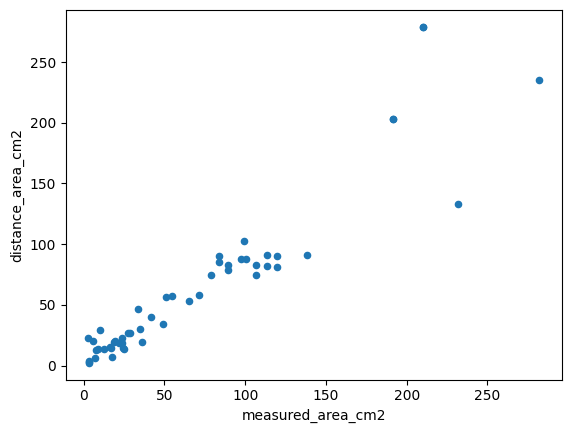

In [49]:
dt1[['measured_area_cm2',  'distance_area_cm2']].plot.scatter(x='measured_area_cm2', y='distance_area_cm2')

In [51]:
from sklearn.metrics import r2_score
# compute R² between measured and predicted areas
y_true = dt1['measured_area_cm2'].to_numpy()
y_pred = dt1['distance_area_cm2'].to_numpy()
mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

if mask.sum() == 0:
    print("No valid samples to compute R²")
else:
    r2 = r2_score(y_true[mask], y_pred[mask])
    print(f"R² = {r2:.4f}  (n={mask.sum()})")

R² = 0.8620  (n=52)


In [52]:
dt1['predicted_area_cm2'] = dt1['distance_area_cm2']

/var/folders/r5/48dgr3g12qg3cwmg9f6v0cwc0000gn/T/ipykernel_2456/902105066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt1['predicted_area_cm2'] = dt1['distance_area_cm2']


Total samples: 52  Outliers detected: 6


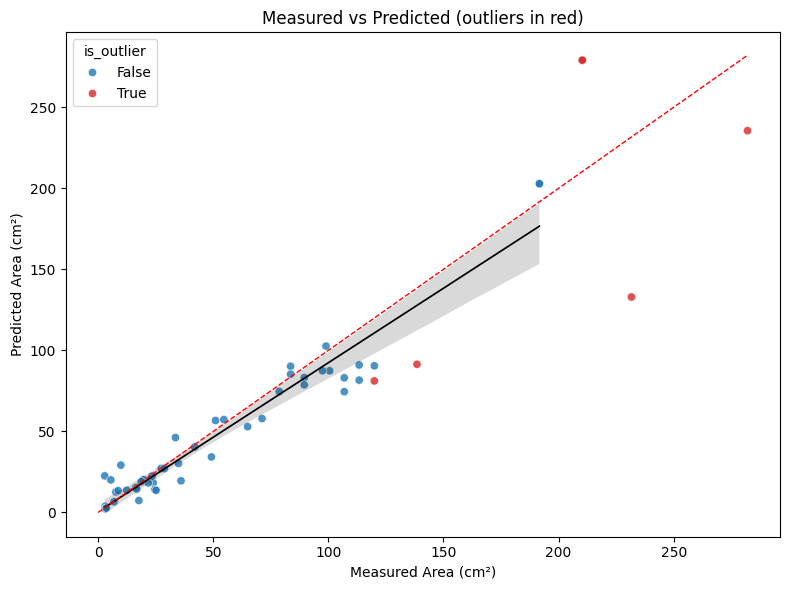

R² (all valid samples): 0.862003081728717
R² (without outliers): 0.9297446909412316


In [54]:
import seaborn as sns
from sklearn.metrics import r2_score
import numpy as np

import matplotlib.pyplot as plt

# work on a copy
df = dt1.dropna(subset=['measured_area_cm2', 'predicted_area_cm2']).copy()
#df = data2.dropna(subset=['measured_area_cm2', 'predicted_area_cm2']).copy()

# df without 177
#df = df[df['file'] != 177].copy()
# df = df[df['file'] != 210].copy()
# df = df[df['file'] != 220].copy()
# df = df[df['file'] != 217].copy()


df['bias'] = df['predicted_area_cm2'] - df['measured_area_cm2']

# use bias (predicted - measured) to find outliers via IQR
Q1 = df['bias'].quantile(0.25)
Q3 = df['bias'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['bias'] < (Q1 - 1.5 * IQR)) | (df['bias'] > (Q3 + 1.5 * IQR))
df['is_outlier'] = outlier_mask

print(f"Total samples: {len(df)}  Outliers detected: {df['is_outlier'].sum()}")

# scatter with outliers highlighted
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='measured_area_cm2',
    y='predicted_area_cm2',
    hue='is_outlier',
    palette={False: 'tab:blue', True: 'tab:red'},
    alpha=0.8
)
# regression line on non-outliers
non_out = df[~df['is_outlier']]
if len(non_out) > 1:
    sns.regplot(
        data=non_out,
        x='measured_area_cm2',
        y='predicted_area_cm2',
        scatter=False,
        color='black',
        line_kws={'linewidth':1.25}
    )

# 45-degree reference line
max_val = max(df['measured_area_cm2'].max(), df['predicted_area_cm2'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1)
plt.xlabel('Measured Area (cm²)')
plt.ylabel('Predicted Area (cm²)')
plt.title('Measured vs Predicted (outliers in red)')
plt.legend(title='is_outlier')
plt.tight_layout()
plt.show()

# compute R² before and after removing outliers
y_true_arr = df['measured_area_cm2'].to_numpy()
y_pred_arr = df['predicted_area_cm2'].to_numpy()
mask_valid = ~np.isnan(y_true_arr) & ~np.isnan(y_pred_arr)

r2_all = np.nan
r2_no_out = np.nan
if mask_valid.sum() > 0:
    try:
        r2_all = r2_score(y_true_arr[mask_valid], y_pred_arr[mask_valid])
    except Exception:
        r2_all = np.nan

no_out_mask = mask_valid & (~df['is_outlier'].to_numpy())
if no_out_mask.sum() > 0:
    try:
        r2_no_out = r2_score(y_true_arr[no_out_mask], y_pred_arr[no_out_mask])
    except Exception:
        r2_no_out = np.nan

print(f"R² (all valid samples): {r2_all}")
print(f"R² (without outliers): {r2_no_out}")

# produce a cleaned dataframe for downstream use
data2_clean = df[~df['is_outlier']].drop(columns=['is_outlier']).reset_index(drop=True)

In [58]:
df

,flower,camera_to_ground_cm,flower_to_ground_cm,flower_to_camera_cm,measured_area_cm2,reference_area_cm2,distance_area_cm2,error_cm2,error_pct,abs_error_pct,image_path,predicted_area_cm2,bias,is_outlier
0,F21,100,16.941884,83.058116,19.696735,18.239009,20.296706,2.057697,11.281846,11.281846,/Users/edwardamoah/Downloads/evaluation_images...,20.296706,0.599972,False
1,F18,60,16.766768,43.233232,35.987025,25.096238,19.537758,-5.558479,-22.148656,22.148656,/Users/edwardamoah/Downloads/evaluation_images...,19.537758,-16.449267,False
2,F13,100,15.437430,84.562570,98.980447,96.598299,102.626389,6.028090,6.240369,6.240369,/Users/edwardamoah/Downloads/evaluation_images...,102.626389,3.645942,False
3,F12,100,16.451947,83.548053,2.883865,21.890223,22.563655,0.673433,3.076408,3.076408,/Users/edwardamoah/Downloads/evaluation_images...,22.563655,19.679790,False
4,F13,60,15.437430,44.562570,231.612440,163.579053,132.928302,-30.650750,-18.737577,18.737577,/Users/edwardamoah/Downloads/evaluation_images...,132.928302,-98.684138,True
6,F18,100,16.766768,83.233232,27.348332,26.554654,27.196349,0.641694,2.416504,2.416504,/Users/edwardamoah/Downloads/evaluation_images...,27.196349,-0.151984,False
7,F17,100,17.466555,82.533445,12.445136,13.174496,13.685038,0.510542,3.875230,3.875230,/Users/edwardamoah/Downloads/evaluation_images...,13.685038,1.239901,False
8,F7,100,17.064556,82.935444,83.599833,74.760453,90.200880,15.440427,20.653201,20.653201,/Users/edwardamoah/Downloads/evaluation_images...,90.200880,6.601047,False
9,F7,100,19.332711,80.667289,83.599833,74.760453,85.334637,10.574184,14.144088,14.144088,/Users/edwardamoah/Downloads/evaluation_images...,85.334637,1.734805,False
10,F1,100,15.690377,84.309623,33.593481,44.887884,46.198990,1.311107,2.920848,2.920848,/Users/edwardamoah/Downloads/evaluation_images...,46.198990,12.605509,False


In [59]:
fl = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment/flower_distance_calibration.csv')

In [61]:
fl.columns.tolist()

['flower',
 'image_path',
 'measured_area_cm2',
 'reference_area_cm2',
 'flower_pixels',
 'camera_to_ground_cm',
 'flower_to_camera_cm',
 'flower_to_ground_cm',
 'focal_length_px',
 'image_width_px']

In [63]:
fl[['flower', 'measured_area_cm2', 'flower_to_ground_cm', 'flower_to_camera_cm']]

,flower,measured_area_cm2,flower_to_ground_cm,flower_to_camera_cm
0,F6,51.309575,10.860592,69.139408
1,F11,3.367735,16.004466,63.995534
2,F13,131.586834,15.437430,64.562570
3,F21,20.451572,16.941884,63.058116
4,F19,33.219288,13.773886,66.226114
5,F10,19.303187,16.762379,63.237621
6,F22,21.477376,16.235536,63.764464
7,F7,101.967538,17.064556,62.935444
8,F18,31.393486,16.766768,63.233232
9,F8,7.677404,17.080416,62.919584


In [64]:
output_folder = "/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment_output"

In [69]:
fl['flower'].tolist()
fl['flower_to_ground_cm'].tolist()
flower_to_ground_dict = fl.set_index('flower')['flower_to_ground_cm'].to_dict()
flower_to_ground_dict

{'F6': 10.86059163888305,
 'F11': 16.00446582196337,
 'F13': 15.437430407990306,
 'F21': 16.94188443116495,
 'F19': 13.773886065376118,
 'F10': 16.762379094735763,
 'F22': 16.235535501209128,
 'F7': 19.332710880344564,
 'F18': 16.766768391384076,
 'F8': 17.080415703873406,
 'F14': 15.81558737560485,
 'F12': 16.45194740619595,
 'F17': 17.466555226576048,
 'F20': 19.10795533851369,
 'F3': 14.377298464464817,
 'F9': 17.065997899848227,
 'F15': 8.396839920196783,
 'F1': 15.690376923380311,
 'F16': 18.667674187374185,
 'F5': 16.135994388141206}

In [71]:
data

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm
0,PXL_20240214_172530114_80cm_F6_.jpg,51.309575,45.372639,/Users/edwardamoah/Downloads/evaluation_images...,F6,80
1,PXL_20240214_173554009_80cm_F11_.jpg,3.367735,3.303557,/Users/edwardamoah/Downloads/evaluation_images...,F11,80
2,PXL_20240214_175708911_100cm_F23_.jpg,35.916057,32.584215,/Users/edwardamoah/Downloads/evaluation_images...,F23,100
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,F21,100
4,PXL_20240214_174000188_80cm_F13_.jpg,131.586834,131.530978,/Users/edwardamoah/Downloads/evaluation_images...,F13,80
...,...,...,...,...,...,...
70,PXL_20240214_172357833_80cm_F5_.jpg,18.845124,11.318141,/Users/edwardamoah/Downloads/evaluation_images...,F5,80
71,PXL_20240214_173607901_60cm_F11_.jpg,3.535477,3.450452,/Users/edwardamoah/Downloads/evaluation_images...,F11,60
72,PXL_20240214_174741393_100cm_F16_.jpg,54.606342,55.910964,/Users/edwardamoah/Downloads/evaluation_images...,F16,100
73,PXL_20240214_172516412_100cm_F6_.jpg,41.935400,36.670874,/Users/edwardamoah/Downloads/evaluation_images...,F6,100


In [159]:
def getDistanceArea(file_path, flower_to_ground_dict, output_folder, distance,  analyzer, flower):
    if distance == 80:
        print(f"Distance {distance}cm not supported for distance based area measurement.")
        return None

    # get flower to ground distance
    flower_to_ground_cm = flower_to_ground_dict.get(flower, None)
    if flower_to_ground_cm is None:
        print(f"Flower {flower} not found in distance calibration data.")
        return None
    
    # estimate flower to camera distance
    flower_to_camera_cm = distance - flower_to_ground_cm
    
    # measure floral area using estimated distance
    result = analyzer.measure(
        file_path,
        flower_threshold=0.5,
        scene_type='indoor',
        flower_distance_cm=flower_to_camera_cm,
        camera_model='pixel_6', 
        output_dir=output_folder
    )
    
    return float(result['all_methods']['distance']['area_cm2'])

In [160]:
data1 = data.copy()

In [161]:
#/Users/edwardamoah/Downloads/evaluation_images_experiment_1/PXL_20240214_175447286_60cm_F21_.jpg
tp = data1[data1['file_path'].str.contains('PXL_20240214_175447286_60cm_F21_.jpg')]

In [162]:
tp[['flower']].values[0][0]

'F21'

In [115]:
flower_to_ground_dict[tp[['flower']].values[0][0]]

16.94188443116495

In [116]:
r = getDistanceArea(tp['file_path'].values[0], flower_to_ground_dict, output_folder, tp['distance_cm'].values[0], analyzer, tp[['flower']].values[0][0])


Measuring: PXL_20240214_175447286_60cm_F21_.jpg

📸 Segmenting flowers and reference (separate calls)...
   Flower: mask_threshold=0.7
Segmenting 'flower' (mask_threshold=0.7)...
✓ Found 6 instances
   ✅ Flowers: 6 detections
   Reference: mask_threshold=0.3 (adaptive)
Segmenting 'brown square cardboard' (mask_threshold=0.3)...
✓ Found 1 instances
   ✅ Reference: 1 detections

🔧 Removing overlapping detections (vectorized NMS)...
      Removing overlapping detection (score: 0.51, IoU: 0.68)
   🔧 NMS: Removed 1 overlapping detections
   ✅ NMS: Kept 5 unique flowers

   Step 2: Scene-adaptive filtering...
      Scene type: INDOOR (5 flowers, user-specified)
      Applying adaptive oversegmentation filter...
   📏 Adaptive threshold: Q3=7.4 + 1.5×IQR=4.3 = 13.8 cm²
   ✅ Final flower pixels: 73,278

📏 Reference quality control...

📏 Processing reference object...
  Single reference detected:
    Aspect ratio: 1.047
    Squareness: 0.932
    ✓ Reference is acceptable
  Reference is square (A

In [117]:
r

18.23744348440354

In [163]:
data1['predicted_distance_area_cm2'] = data1.apply(
    lambda row: getDistanceArea(
        row['file_path'], 
        flower_to_ground_dict, 
        output_folder, 
        row['distance_cm'], 
        analyzer,
        row['flower']
    ), axis=1
)

Distance 80cm not supported for distance based area measurement.
Distance 80cm not supported for distance based area measurement.
Flower F23 not found in distance calibration data.

Measuring: PXL_20240214_175352365_100cm_F21_.jpg

📸 Segmenting flowers and reference (separate calls)...
   Flower: mask_threshold=0.7
Segmenting 'flower' (mask_threshold=0.7)...
✓ Found 5 instances
   ✅ Flowers: 5 detections
   Reference: mask_threshold=0.3 (adaptive)
Segmenting 'brown square cardboard' (mask_threshold=0.3)...
✓ Found 1 instances
   ✅ Reference: 1 detections

🔧 Removing overlapping detections (vectorized NMS)...

   Step 2: Scene-adaptive filtering...
      Scene type: INDOOR (5 flowers, user-specified)
      Applying adaptive oversegmentation filter...
   📏 Adaptive threshold: Q3=5.4 + 1.5×IQR=2.6 = 9.2 cm²
   ✅ Final flower pixels: 21,917

📏 Reference quality control...

📏 Processing reference object...
  Single reference detected:
    Aspect ratio: 1.052
    Squareness: 0.925
    ✓ Refe

In [310]:
data2 = data1.dropna(subset=['predicted_distance_area_cm2'])

In [245]:
len(data2)

46

In [246]:
data2.groupby('flower').count()

,file,measured_area_cm2,predicted_area_cm2,file_path,distance_cm,predicted_distance_area_cm2
flower,,,,,,
F1,2,2,2,2,2,2
F10,2,2,2,2,2,2
F11,3,3,3,3,3,3
F12,2,2,2,2,2,2
F13,3,3,3,3,3,3
F14,2,2,2,2,2,2
F15,2,2,2,2,2,2
F16,2,2,2,2,2,2
F17,2,2,2,2,2,2


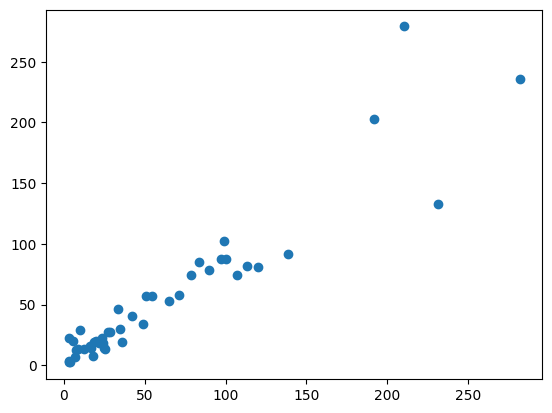

In [249]:
data2 = data2[data2['predicted_distance_area_cm2'] < 500]
plt.scatter(data2['measured_area_cm2'], data2['predicted_distance_area_cm2'])

In [250]:
# compute R² for data2
if 'data2' not in globals():
    raise NameError("data2 not found. Run previous cells that create data2.")

y_true = data2['measured_area_cm2'].to_numpy()
y_pred = data2['predicted_distance_area_cm2'].to_numpy()
mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

if mask.sum() == 0:
    print("No valid samples to compute R²")
else:
    r2 = r2_score(y_true[mask], y_pred[mask])
    print(f"R² (all valid samples) = {r2:.6f}  (n={mask.sum()})")
    if 'is_outlier' in data2.columns:
        no_out_mask = mask & (~data2['is_outlier'].to_numpy())
        if no_out_mask.sum() > 0:
            r2_no_out = r2_score(y_true[no_out_mask], y_pred[no_out_mask])
            print(f"R² (without outliers) = {r2_no_out:.6f}  (n={no_out_mask.sum()})")

R² (all valid samples) = 0.865297  (n=45)


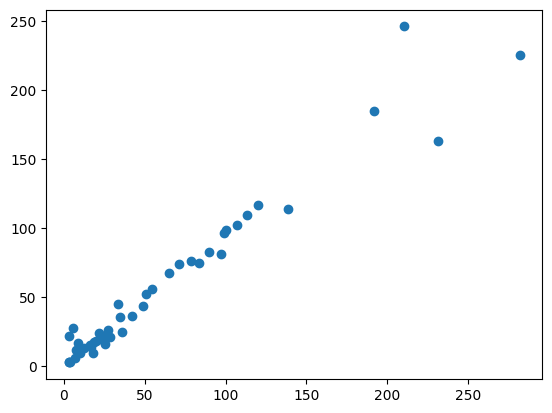

In [251]:
data2 = data2[data2['predicted_area_cm2'] < 500]
plt.scatter(data2['measured_area_cm2'], data2['predicted_area_cm2'])

In [171]:
# compute R² for data2
if 'data2' not in globals():
    raise NameError("data2 not found. Run previous cells that create data2.")

y_true = data2['measured_area_cm2'].to_numpy()
y_pred = data2['predicted_area_cm2'].to_numpy()
mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

if mask.sum() == 0:
    print("No valid samples to compute R²")
else:
    r2 = r2_score(y_true[mask], y_pred[mask])
    print(f"R² (all valid samples) = {r2:.6f}  (n={mask.sum()})")
    if 'is_outlier' in data2.columns:
        no_out_mask = mask & (~data2['is_outlier'].to_numpy())
        if no_out_mask.sum() > 0:
            r2_no_out = r2_score(y_true[no_out_mask], y_pred[no_out_mask])
            print(f"R² (without outliers) = {r2_no_out:.6f}  (n={no_out_mask.sum()})")

R² (all valid samples) = 0.938031  (n=45)


In [173]:
len(data2)

45

In [175]:
data2[['file','flower', 'distance_cm','measured_area_cm2', 'predicted_distance_area_cm2', 'predicted_area_cm2']].to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment/distance_based_area_analysis_data.csv', index=False)

In [176]:
dt = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/distance_experiment/distance_measurement_evaluation.csv')

In [205]:
dt['filename'] = dt['image_path'].apply(lambda x: x.split("/")[-1])

In [206]:
flower = 'F7'
dt[dt['flower'] == flower][['filename','measured_area_cm2', 'reference_area_cm2','distance_area_cm2', 'camera_to_ground_cm']]

,filename,measured_area_cm2,reference_area_cm2,distance_area_cm2,camera_to_ground_cm
8,PXL_20240214_172902391_100cm_F7_.jpg,83.599833,74.760453,90.200880,100
9,PXL_20240214_172902391_100cm_F7_.jpg,83.599833,74.760453,85.334637,100
11,PXL_20240214_172812015_60cm_F7_.jpg,119.967502,116.620480,90.464716,60
12,PXL_20240214_172812015_60cm_F7_.jpg,119.967502,116.620480,81.159198,60
29,PXL_20240214_172844073_60cm_F7_.jpg,106.896560,102.049540,83.039060,60
30,PXL_20240214_172844073_60cm_F7_.jpg,106.896560,102.049540,74.497371,60
41,PXL_20240214_172835282_60cm_F7_.jpg,113.380418,109.658119,90.987113,60
42,PXL_20240214_172835282_60cm_F7_.jpg,113.380418,109.658119,81.627859,60
48,PXL_20240214_172735080_100cm_F7_.jpg,89.522402,82.474999,83.212136,100
49,PXL_20240214_172735080_100cm_F7_.jpg,89.522402,82.474999,78.722928,100


In [207]:
data2[data2['flower'] == flower][['file','measured_area_cm2', 'predicted_area_cm2', 'predicted_distance_area_cm2', 'distance_cm']]

,file,measured_area_cm2,predicted_area_cm2,predicted_distance_area_cm2,distance_cm
15,PXL_20240214_172902391_100cm_F7_.jpg,83.599833,74.760453,85.334637,100
17,PXL_20240214_172812015_60cm_F7_.jpg,119.967502,116.620480,81.159198,60
41,PXL_20240214_172844073_60cm_F7_.jpg,106.896560,102.049540,74.497371,60
60,PXL_20240214_172835282_60cm_F7_.jpg,113.380418,109.658119,81.627859,60
69,PXL_20240214_172735080_100cm_F7_.jpg,89.522402,82.474999,78.722928,100


In [211]:
dt.drop_duplicates(subset=['filename']).groupby('flower').count()

,camera_to_ground_cm,flower_to_ground_cm,flower_to_camera_cm,measured_area_cm2,reference_area_cm2,distance_area_cm2,error_cm2,error_pct,abs_error_pct,image_path,filename
flower,,,,,,,,,,,
F1,2,2,2,2,2,2,2,2,2,2,2
F10,2,2,2,2,2,2,2,2,2,2,2
F11,3,3,3,3,3,3,3,3,3,3,3
F12,2,2,2,2,2,2,2,2,2,2,2
F13,3,3,3,3,3,3,3,3,3,3,3
F14,2,2,2,2,2,2,2,2,2,2,2
F15,2,2,2,2,2,2,2,2,2,2,2
F16,2,2,2,2,2,2,2,2,2,2,2
F17,2,2,2,2,2,2,2,2,2,2,2


In [213]:
data2.groupby('flower').count()

,file,measured_area_cm2,predicted_area_cm2,file_path,distance_cm,predicted_distance_area_cm2
flower,,,,,,
F1,2,2,2,2,2,2
F10,2,2,2,2,2,2
F11,3,3,3,3,3,3
F12,2,2,2,2,2,2
F13,3,3,3,3,3,3
F14,2,2,2,2,2,2
F15,1,1,1,1,1,1
F16,2,2,2,2,2,2
F17,2,2,2,2,2,2


In [ ]:
data['is_distance_based'] = data['predicted_distance_area_cm2'].notna()

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm
0,PXL_20240214_172530114_80cm_F6_.jpg,51.309575,45.372639,/Users/edwardamoah/Downloads/evaluation_images...,F6,80
1,PXL_20240214_173554009_80cm_F11_.jpg,3.367735,3.303557,/Users/edwardamoah/Downloads/evaluation_images...,F11,80
2,PXL_20240214_175708911_100cm_F23_.jpg,35.916057,32.584215,/Users/edwardamoah/Downloads/evaluation_images...,F23,100
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,F21,100
4,PXL_20240214_174000188_80cm_F13_.jpg,131.586834,131.530978,/Users/edwardamoah/Downloads/evaluation_images...,F13,80
...,...,...,...,...,...,...
70,PXL_20240214_172357833_80cm_F5_.jpg,18.845124,11.318141,/Users/edwardamoah/Downloads/evaluation_images...,F5,80
71,PXL_20240214_173607901_60cm_F11_.jpg,3.535477,3.450452,/Users/edwardamoah/Downloads/evaluation_images...,F11,60
72,PXL_20240214_174741393_100cm_F16_.jpg,54.606342,55.910964,/Users/edwardamoah/Downloads/evaluation_images...,F16,100
73,PXL_20240214_172516412_100cm_F6_.jpg,41.935400,36.670874,/Users/edwardamoah/Downloads/evaluation_images...,F6,100


In [221]:
def isDistanceBased(flower):
    if flower in flower_to_ground_dict:
        return True
    return False

In [226]:
data['isFlowerDistanceBased'] = data['flower'].apply(isDistanceBased)

In [228]:
data3 = data.query('isFlowerDistanceBased == True and distance_cm != 80')

In [230]:
len(data3)

46

In [235]:
data2['file'].tolist()

['PXL_20240214_175352365_100cm_F21_.jpg',
 'PXL_20240214_175033319_60cm_F18_.jpg',
 'PXL_20240214_173904525_100cm_F13_.jpg',
 'PXL_20240214_173731980_100cm_F12_.jpg',
 'PXL_20240214_174053319_60cm_F13_.jpg',
 'PXL_20240214_175016038_100cm_F18_.jpg',
 'PXL_20240214_174857541_100cm_F17_.jpg',
 'PXL_20240214_172902391_100cm_F7_.jpg',
 'PXL_20240214_171637048_100cm_F1_.jpg',
 'PXL_20240214_172812015_60cm_F7_.jpg',
 'PXL_20240214_172005738_100cm_F3_.jpg',
 'PXL_20240214_175600353_100cm_F22_.jpg',
 'PXL_20240214_174424831_90cm_F14_.jpg',
 'PXL_20240214_174325426_100cm_F14_.jpg',
 'PXL_20240214_171937537_100cm_F3_.jpg',
 'PXL_20240214_173542045_100cm_F11_.jpg',
 'PXL_20240214_174810162_60cm_F16_.jpg',
 'PXL_20240214_173058624_100cm_F8_.jpg',
 'PXL_20240214_173256770_60cm_F9_.jpg',
 'PXL_20240214_173605233_60cm_F11_.jpg',
 'PXL_20240214_173124719_60cm_F8_.jpg',
 'PXL_20240214_173951011_90cm_F13_.jpg',
 'PXL_20240214_175112414_100cm_F19_.jpg',
 'PXL_20240214_173235450_100cm_F9_.jpg',
 'PXL_2024

In [253]:
for file in data3['file'].tolist():
    if file not in data2['file'].tolist():
        print(f"Missing file: {file}")

Missing file: PXL_20240214_174619635_100cm_F15_.jpg


In [259]:
data3[data3['file'] == 'PXL_20240214_174619635_100cm_F15_.jpg']

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm,isFlowerDistanceBased
11,PXL_20240214_174619635_100cm_F15_.jpg,359.605732,296.924253,/Users/edwardamoah/Downloads/evaluation_images...,F15,100,True


In [261]:
len(data3)

46

In [266]:
data3['file'].tolist()

['PXL_20240214_175352365_100cm_F21_.jpg',
 'PXL_20240214_175033319_60cm_F18_.jpg',
 'PXL_20240214_173904525_100cm_F13_.jpg',
 'PXL_20240214_173731980_100cm_F12_.jpg',
 'PXL_20240214_174053319_60cm_F13_.jpg',
 'PXL_20240214_174619635_100cm_F15_.jpg',
 'PXL_20240214_175016038_100cm_F18_.jpg',
 'PXL_20240214_174857541_100cm_F17_.jpg',
 'PXL_20240214_172902391_100cm_F7_.jpg',
 'PXL_20240214_171637048_100cm_F1_.jpg',
 'PXL_20240214_172812015_60cm_F7_.jpg',
 'PXL_20240214_172005738_100cm_F3_.jpg',
 'PXL_20240214_175600353_100cm_F22_.jpg',
 'PXL_20240214_174424831_90cm_F14_.jpg',
 'PXL_20240214_174325426_100cm_F14_.jpg',
 'PXL_20240214_171937537_100cm_F3_.jpg',
 'PXL_20240214_173542045_100cm_F11_.jpg',
 'PXL_20240214_174810162_60cm_F16_.jpg',
 'PXL_20240214_173058624_100cm_F8_.jpg',
 'PXL_20240214_173256770_60cm_F9_.jpg',
 'PXL_20240214_173605233_60cm_F11_.jpg',
 'PXL_20240214_173124719_60cm_F8_.jpg',
 'PXL_20240214_173951011_90cm_F13_.jpg',
 'PXL_20240214_175112414_100cm_F19_.jpg',
 'PXL_202

In [263]:
data4 = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_distance_based_analysis_data.csv')

In [265]:
data4['file'].tolist()

['PXL_20240214_175352365_100cm_F21_.jpg',
 'PXL_20240214_175033319_60cm_F18_.jpg',
 'PXL_20240214_173904525_100cm_F13_.jpg',
 'PXL_20240214_173731980_100cm_F12_.jpg',
 'PXL_20240214_174053319_60cm_F13_.jpg',
 'PXL_20240214_175016038_100cm_F18_.jpg',
 'PXL_20240214_174857541_100cm_F17_.jpg',
 'PXL_20240214_172902391_100cm_F7_.jpg',
 'PXL_20240214_171637048_100cm_F1_.jpg',
 'PXL_20240214_172812015_60cm_F7_.jpg',
 'PXL_20240214_172005738_100cm_F3_.jpg',
 'PXL_20240214_175600353_100cm_F22_.jpg',
 'PXL_20240214_174424831_90cm_F14_.jpg',
 'PXL_20240214_174325426_100cm_F14_.jpg',
 'PXL_20240214_171937537_100cm_F3_.jpg',
 'PXL_20240214_173542045_100cm_F11_.jpg',
 'PXL_20240214_174810162_60cm_F16_.jpg',
 'PXL_20240214_173058624_100cm_F8_.jpg',
 'PXL_20240214_173256770_60cm_F9_.jpg',
 'PXL_20240214_173605233_60cm_F11_.jpg',
 'PXL_20240214_173124719_60cm_F8_.jpg',
 'PXL_20240214_173951011_90cm_F13_.jpg',
 'PXL_20240214_175112414_100cm_F19_.jpg',
 'PXL_20240214_173235450_100cm_F9_.jpg',
 'PXL_2024

In [267]:
for file in data3['file'].tolist():
    if file not in data4['file'].tolist():
        print(file)

PXL_20240214_174619635_100cm_F15_.jpg


In [268]:
data3.head()

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm,isFlowerDistanceBased
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,F21,100,True
6,PXL_20240214_175033319_60cm_F18_.jpg,35.987025,25.096238,/Users/edwardamoah/Downloads/evaluation_images...,F18,60,True
7,PXL_20240214_173904525_100cm_F13_.jpg,98.980447,96.598299,/Users/edwardamoah/Downloads/evaluation_images...,F13,100,True
8,PXL_20240214_173731980_100cm_F12_.jpg,2.883865,21.890223,/Users/edwardamoah/Downloads/evaluation_images...,F12,100,True
10,PXL_20240214_174053319_60cm_F13_.jpg,231.612440,163.579053,/Users/edwardamoah/Downloads/evaluation_images...,F13,60,True


In [269]:
data4.head()

,file,flower,distance_camera_to_ground_cm,measured_area_cm2,predicted_distance_based_area_cm2,predicted_reference_based_area_cm2
0,PXL_20240214_175352365_100cm_F21_.jpg,F21,100,19.696735,20.296706,18.239009
1,PXL_20240214_175033319_60cm_F18_.jpg,F18,60,35.987025,19.537758,25.096238
2,PXL_20240214_173904525_100cm_F13_.jpg,F13,100,98.980447,102.626389,96.598299
3,PXL_20240214_173731980_100cm_F12_.jpg,F12,100,2.883865,22.563655,21.890223
4,PXL_20240214_174053319_60cm_F13_.jpg,F13,60,231.612440,132.928302,163.579053


In [274]:
dt

,flower,camera_to_ground_cm,flower_to_ground_cm,flower_to_camera_cm,measured_area_cm2,reference_area_cm2,distance_area_cm2,error_cm2,error_pct,abs_error_pct,image_path,filename
0,F21,100,16.941884,83.058116,19.696735,18.239009,20.296706,2.057697,11.281846,11.281846,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_175352365_100cm_F21_.jpg
1,F18,60,16.766768,43.233232,35.987025,25.096238,19.537758,-5.558479,-22.148656,22.148656,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_175033319_60cm_F18_.jpg
2,F13,100,15.437430,84.562570,98.980447,96.598299,102.626389,6.028090,6.240369,6.240369,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_173904525_100cm_F13_.jpg
3,F12,100,16.451947,83.548053,2.883865,21.890223,22.563655,0.673433,3.076408,3.076408,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_173731980_100cm_F12_.jpg
4,F13,60,15.437430,44.562570,231.612440,163.579053,132.928302,-30.650750,-18.737577,18.737577,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_174053319_60cm_F13_.jpg
5,F15,100,8.396840,91.603160,359.605732,296.924253,816.384798,519.460545,174.947159,174.947159,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_174619635_100cm_F15_.jpg
6,F18,100,16.766768,83.233232,27.348332,26.554654,27.196349,0.641694,2.416504,2.416504,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_175016038_100cm_F18_.jpg
7,F17,100,17.466555,82.533445,12.445136,13.174496,13.685038,0.510542,3.875230,3.875230,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_174857541_100cm_F17_.jpg
8,F7,100,17.064556,82.935444,83.599833,74.760453,90.200880,15.440427,20.653201,20.653201,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_172902391_100cm_F7_.jpg
9,F7,100,19.332711,80.667289,83.599833,74.760453,85.334637,10.574184,14.144088,14.144088,/Users/edwardamoah/Downloads/evaluation_images...,PXL_20240214_172902391_100cm_F7_.jpg


In [276]:
data5 = dt[['filename','measured_area_cm2','reference_area_cm2','distance_area_cm2', 'flower', 'camera_to_ground_cm']]

In [277]:
data4.head()

,file,flower,distance_camera_to_ground_cm,measured_area_cm2,predicted_distance_based_area_cm2,predicted_reference_based_area_cm2
0,PXL_20240214_175352365_100cm_F21_.jpg,F21,100,19.696735,20.296706,18.239009
1,PXL_20240214_175033319_60cm_F18_.jpg,F18,60,35.987025,19.537758,25.096238
2,PXL_20240214_173904525_100cm_F13_.jpg,F13,100,98.980447,102.626389,96.598299
3,PXL_20240214_173731980_100cm_F12_.jpg,F12,100,2.883865,22.563655,21.890223
4,PXL_20240214_174053319_60cm_F13_.jpg,F13,60,231.612440,132.928302,163.579053


In [302]:
data2.head()

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm,predicted_distance_area_cm2
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,F21,100,20.296706
6,PXL_20240214_175033319_60cm_F18_.jpg,35.987025,25.096238,/Users/edwardamoah/Downloads/evaluation_images...,F18,60,19.537758
7,PXL_20240214_173904525_100cm_F13_.jpg,98.980447,96.598299,/Users/edwardamoah/Downloads/evaluation_images...,F13,100,102.626389
8,PXL_20240214_173731980_100cm_F12_.jpg,2.883865,21.890223,/Users/edwardamoah/Downloads/evaluation_images...,F12,100,22.563655
10,PXL_20240214_174053319_60cm_F13_.jpg,231.612440,163.579053,/Users/edwardamoah/Downloads/evaluation_images...,F13,60,132.928302


In [313]:
data6 = data2.rename(
    columns={
        "predicted_area_cm2": "predicted_reference_based_area_cm2",
        "predicted_distance_area_cm2": "predicted_distance_based_area_cm2",
        "distance_cm": "distance_camera_to_ground_cm"
    }
)
data7 = data6[['file','flower','distance_camera_to_ground_cm','measured_area_cm2','predicted_reference_based_area_cm2','predicted_distance_based_area_cm2']]

In [314]:
len(data7)

46

In [315]:
data7.to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_distance_based_analysis_data_v2.csv')

In [317]:
data1

,file,measured_area_cm2,predicted_area_cm2,file_path,flower,distance_cm,predicted_distance_area_cm2
0,PXL_20240214_172530114_80cm_F6_.jpg,51.309575,45.372639,/Users/edwardamoah/Downloads/evaluation_images...,F6,80,NaN
1,PXL_20240214_173554009_80cm_F11_.jpg,3.367735,3.303557,/Users/edwardamoah/Downloads/evaluation_images...,F11,80,NaN
2,PXL_20240214_175708911_100cm_F23_.jpg,35.916057,32.584215,/Users/edwardamoah/Downloads/evaluation_images...,F23,100,NaN
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009,/Users/edwardamoah/Downloads/evaluation_images...,F21,100,20.296706
4,PXL_20240214_174000188_80cm_F13_.jpg,131.586834,131.530978,/Users/edwardamoah/Downloads/evaluation_images...,F13,80,NaN
...,...,...,...,...,...,...,...
70,PXL_20240214_172357833_80cm_F5_.jpg,18.845124,11.318141,/Users/edwardamoah/Downloads/evaluation_images...,F5,80,NaN
71,PXL_20240214_173607901_60cm_F11_.jpg,3.535477,3.450452,/Users/edwardamoah/Downloads/evaluation_images...,F11,60,2.716834
72,PXL_20240214_174741393_100cm_F16_.jpg,54.606342,55.910964,/Users/edwardamoah/Downloads/evaluation_images...,F16,100,57.300037
73,PXL_20240214_172516412_100cm_F6_.jpg,41.935400,36.670874,/Users/edwardamoah/Downloads/evaluation_images...,F6,100,40.392771


In [318]:
flower_to_ground_dict

{'F6': 10.86059163888305,
 'F11': 16.00446582196337,
 'F13': 15.437430407990306,
 'F21': 16.94188443116495,
 'F19': 13.773886065376118,
 'F10': 16.762379094735763,
 'F22': 16.235535501209128,
 'F7': 19.332710880344564,
 'F18': 16.766768391384076,
 'F8': 17.080415703873406,
 'F14': 15.81558737560485,
 'F12': 16.45194740619595,
 'F17': 17.466555226576048,
 'F20': 19.10795533851369,
 'F3': 14.377298464464817,
 'F9': 17.065997899848227,
 'F15': 8.396839920196783,
 'F1': 15.690376923380311,
 'F16': 18.667674187374185,
 'F5': 16.135994388141206}

In [320]:
data7['distance_flower_to_ground_cm'] = data7['flower'].apply(lambda x: flower_to_ground_dict[x])

In [321]:
data7

,file,flower,distance_camera_to_ground_cm,measured_area_cm2,predicted_reference_based_area_cm2,predicted_distance_based_area_cm2,distance_flower_to_ground_cm
3,PXL_20240214_175352365_100cm_F21_.jpg,F21,100,19.696735,18.239009,20.296706,16.941884
6,PXL_20240214_175033319_60cm_F18_.jpg,F18,60,35.987025,25.096238,19.537758,16.766768
7,PXL_20240214_173904525_100cm_F13_.jpg,F13,100,98.980447,96.598299,102.626389,15.437430
8,PXL_20240214_173731980_100cm_F12_.jpg,F12,100,2.883865,21.890223,22.563655,16.451947
10,PXL_20240214_174053319_60cm_F13_.jpg,F13,60,231.612440,163.579053,132.928302,15.437430
11,PXL_20240214_174619635_100cm_F15_.jpg,F15,100,359.605732,296.924253,816.384798,8.396840
12,PXL_20240214_175016038_100cm_F18_.jpg,F18,100,27.348332,26.554654,27.196349,16.766768
14,PXL_20240214_174857541_100cm_F17_.jpg,F17,100,12.445136,13.174496,13.685038,17.466555
15,PXL_20240214_172902391_100cm_F7_.jpg,F7,100,83.599833,74.760453,85.334637,19.332711
16,PXL_20240214_171637048_100cm_F1_.jpg,F1,100,33.593481,44.887884,46.198990,15.690377


In [322]:
data7.to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_distance_based_analysis_data.csv')